<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Mini%20Project/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import accuracy_score

## 2. Load Dataset

In [104]:
# Import dataset from github
dataset_url = 'https://raw.githubusercontent.com/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/refs/heads/main/Mini%20Project/Student_performance_data%20_.csv'
df = pd.read_csv(dataset_url)

## 3. Eksplorasi Data Awal (EDA)


In [105]:
print(df.info())
print()

# cek missing value
print('=== Missing Value ===')
print(df.isnull().sum())

# Distribusi Kelas Target
print('\n=== DISTRIBUSI KELAS ===')
print(df['GradeClass'].value_counts())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None

=== Missing Value 

## 4. Preprocessing

In [106]:
# Menghapus StudentID karena noise
df = df.drop(columns=['StudentID'], errors='ignore')

# One-Hot Encoding pada 'Ethnicity' agar tidak menjadi data ordinal
df = pd.get_dummies(df, columns=['Ethnicity'], drop_first=True)

print("Kolom setelah Encoding:\n", df.columns)

Kolom setelah Encoding:
 Index(['Age', 'Gender', 'ParentalEducation', 'StudyTimeWeekly', 'Absences',
       'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music',
       'Volunteering', 'GPA', 'GradeClass', 'Ethnicity_1', 'Ethnicity_2',
       'Ethnicity_3'],
      dtype='object')


## 5. Ekplorasi data lanjutan

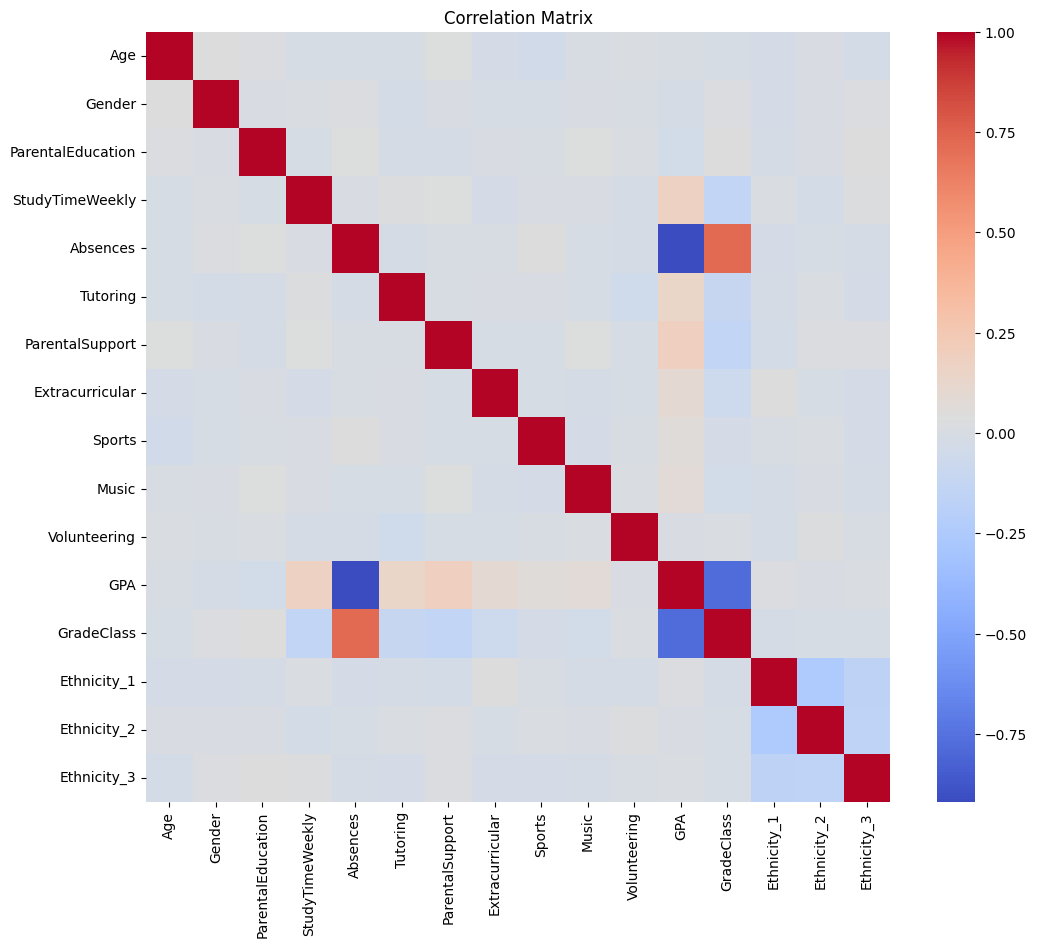

In [107]:
# Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

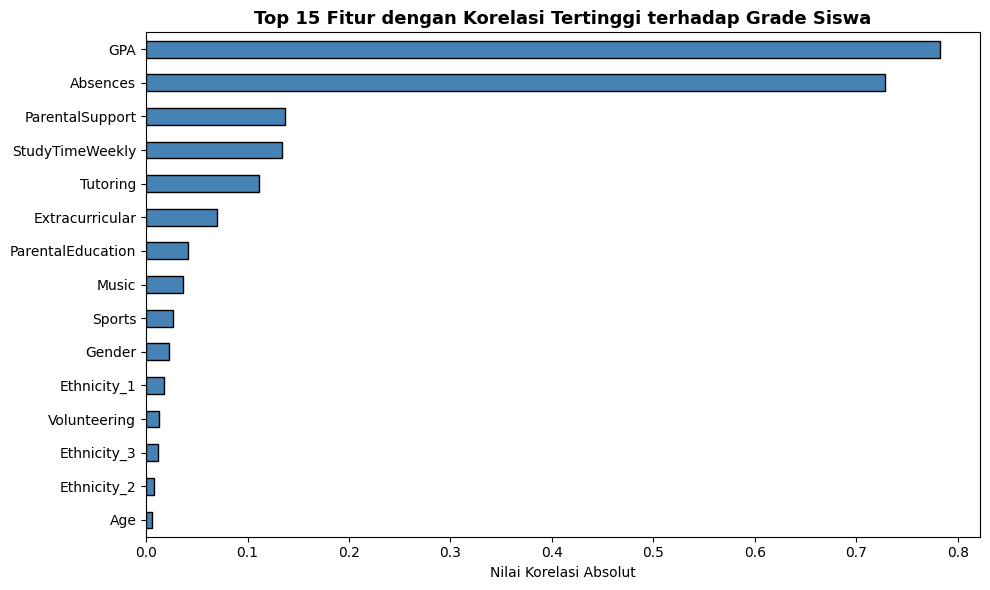

Fitur paling berpengaruh terhadap nilai siswa adalah: GPA


In [108]:
# Korelasi Fitur dengan Target (GradeClass)
df_corr = df.drop(columns=['StudentID'], errors='ignore').copy()
corr_with_target = df_corr.drop(columns=['GradeClass']).corrwith(df_corr['GradeClass'])
corr_sorted = corr_with_target.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
corr_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Fitur dengan Korelasi Tertinggi terhadap Grade Siswa', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Korelasi Absolut')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('korelasi_fitur_students.png', dpi=150, bbox_inches='tight')
plt.show()

print('Fitur paling berpengaruh terhadap nilai siswa adalah:', corr_sorted.index[0])

## 6. Split Dataset & Feature Scaling

In [109]:
X = df.drop("GradeClass", axis=1)
y = df["GradeClass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Bentuk X_train_scaled:", X_train_scaled.shape)

Bentuk X_train_scaled: (1674, 15)


## 7. PCA

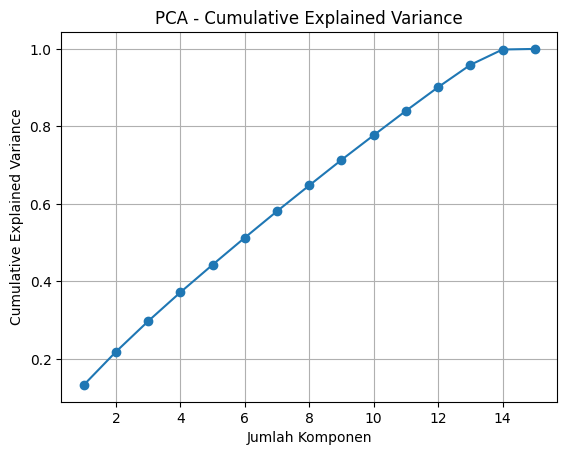

In [110]:
# analisis Explained Variance + Cumulative
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid()
plt.show()

In [111]:
# PCA 90% Variance
pca = PCA(n_components=0.90)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Jumlah komponen untuk 90% variance:", pca_90.n_components_)

Jumlah komponen untuk 90% variance: 12


## 8. Baseline Model

In [112]:
# Logistic Regression
log = LogisticRegression(max_iter=5000, random_state=42)
log.fit(X_train_scaled, y_train)

acc_log = accuracy_score(y_test, log.predict(X_test_scaled))
cv_log = cross_val_score(log, X_train_scaled, y_train, cv=5).mean()

In [113]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()

In [114]:
# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
cv_svm = cross_val_score(svm, X_train_scaled, y_train, cv=5).mean()

## 9. Implementasi PCA

In [115]:
# SVM + PCA
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_train_pca, y_train)

acc_svm_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))
cv_svm_pca = cross_val_score(svm_pca, X_train_pca, y_train, cv=5).mean()

In [116]:
# KNN + PCA
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

acc_knn_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))
cv_knn_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=5).mean()

## 10. Ensemble

In [117]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

acc_rf = accuracy_score(y_test, rf.predict(X_test_scaled))
cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5).mean()

In [118]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

acc_gb = accuracy_score(y_test, gb.predict(X_test_scaled))
cv_gb = cross_val_score(gb, X_train_scaled, y_train, cv=5).mean()

In [119]:
# Voting
voting = VotingClassifier(
    estimators=[
        ('log', LogisticRegression(max_iter=5000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting='soft'
)

voting.fit(X_train_scaled, y_train)

acc_vote = accuracy_score(y_test, voting.predict(X_test_scaled))
cv_vote = cross_val_score(voting, X_train_scaled, y_train, cv=5).mean()

## 11. Hyperparameter Tuning : GridSearchCV

In [120]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_

acc_tuned = accuracy_score(y_test, best_rf.predict(X_test_scaled))
cv_tuned = grid.best_score_

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


## 12. Tabel Hasil Eksperimen

In [121]:
results = pd.DataFrame({
    'Model': [
        'Logistic',
        'KNN',
        'SVM',
        'SVM + PCA',
        'KNN + PCA',
        'Random Forest',
        'Gradient Boosting',
        'Voting',
        'Random Forest (Tuned)'
    ],
    'Test Accuracy': [
        acc_log,
        acc_knn,
        acc_svm,
        acc_svm_pca,
        acc_knn_pca,
        acc_rf,
        acc_gb,
        acc_vote,
        acc_tuned
    ],
    'CV Score': [
        cv_log,
        cv_knn,
        cv_svm,
        cv_svm_pca,
        cv_knn_pca,
        cv_rf,
        cv_gb,
        cv_vote,
        cv_tuned
    ]
})

print(results)

                   Model  Test Accuracy  CV Score
0               Logistic       0.793872  0.786140
1                    KNN       0.594708  0.609903
2                    SVM       0.799443  0.781959
3              SVM + PCA       0.806407  0.783748
4              KNN + PCA       0.626741  0.629627
5          Random Forest       0.919220  0.909213
6      Gradient Boosting       0.923398  0.921156
7                 Voting       0.933148  0.926535
8  Random Forest (Tuned)       0.916435  0.911002
